<a href="https://colab.research.google.com/github/Vaishnavi200527/RollNo_39_MLDL_Lab/blob/main/mldllab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
data = pd.read_csv("/content/dermatology_database_1.csv")

In [8]:
data.replace('?', np.nan, inplace=True)
data = data.apply(pd.to_numeric)
data.fillna(data.mean(), inplace=True)

In [5]:
X = data.drop("class", axis=1)
y = data["class"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [10]:
y_pred = knn.predict(X_test)


In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9727272727272728

Confusion Matrix:
 [[40  0  0  0  0  0]
 [ 0 15  0  1  0  0]
 [ 0  0 19  0  0  0]
 [ 0  2  0 13  0  0]
 [ 0  0  0  0 16  0]
 [ 0  0  0  0  0  4]]

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        40
           2       0.88      0.94      0.91        16
           3       1.00      1.00      1.00        19
           4       0.93      0.87      0.90        15
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00         4

    accuracy                           0.97       110
   macro avg       0.97      0.97      0.97       110
weighted avg       0.97      0.97      0.97       110



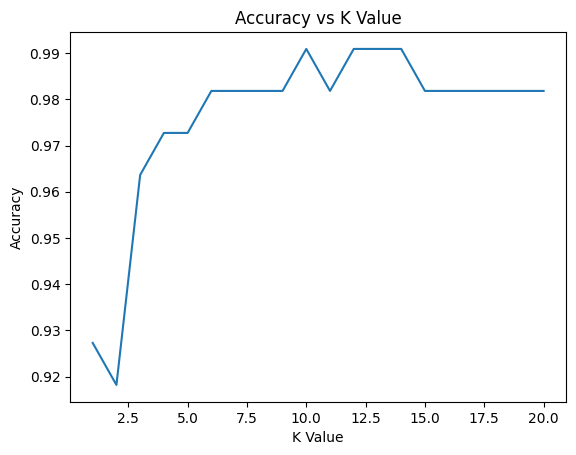

Best Accuracy: 0.990909090909091
Best K: 10


In [11]:
accuracy_list = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, pred))

plt.plot(range(1,21), accuracy_list)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K Value")
plt.show()

print("Best Accuracy:", max(accuracy_list))
print("Best K:", accuracy_list.index(max(accuracy_list)) + 1)